In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import parscan_utils as pu
import parscan_plots as pp
for m in (co, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

In [5]:
# SMOKE TEST piece-1 — confirm avg_tail_stats populates CV + the flag columns render.
# Low/stable F_N only, so the default instability guard is fine here.
import importlib, numpy as np
import baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
importlib.reload(pue); importlib.reload(brs)        # pick up avg_tail_stats + flags
from xso.parscans import run_xso_parscan

_, _, _, mdf, forcing = co.load_cariaco_targets('upwelling', months='hplc',
                                                agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(mdf)


In [ ]:
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name='Inflow__FN',
    param_values=np.array([1.0, 2.0, 3.0]),
    fixed_overrides={k: v for k, v in forcing.items() if k != 'Inflow__FN'},
    postprocess_name='avg_tail_stats',              # <-- the new hook
    postprocess_kwargs={'avg_window': 1000},
    processes=3,
)
m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': forcing['Inflow__de']})
print('cv_sumP present:', 'cv_sumP' in m, '->', np.asarray(m.get('cv_sumP')))
pue.print_scan_table_1d(m, obs_refs, 'SMOKE — avg_tail_stats', axis_label='F_N')

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 24 points using 8 workers...
1D Scan complete. Time taken: 32.58138 seconds.

=== Construct-0 (Taniguchi μ + uniform m_P, Type III, fish off) — F_N sweep @ upwelling d_e/T ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp      CV  flag
 0.500   1.42   0.141   0.076   0.000   0.217  0.0000  0.0000   0.074   0.022   0.098   0.026   0.488  0.0025     c
 1.000   2.01   0.175   0.094   0.028   0.297  0.0001  0.0000   0.117   0.037   0.194   0.053   0.971  0.0118      
 1.500   3.10   0.196   0.089   0.082   0.367  0.0039  0.0000   0.153   0.053   0.290   0.081   1.450  0.0106      
 2.000   4.06   0.214   0.082   0.132   0.428  0.0056  

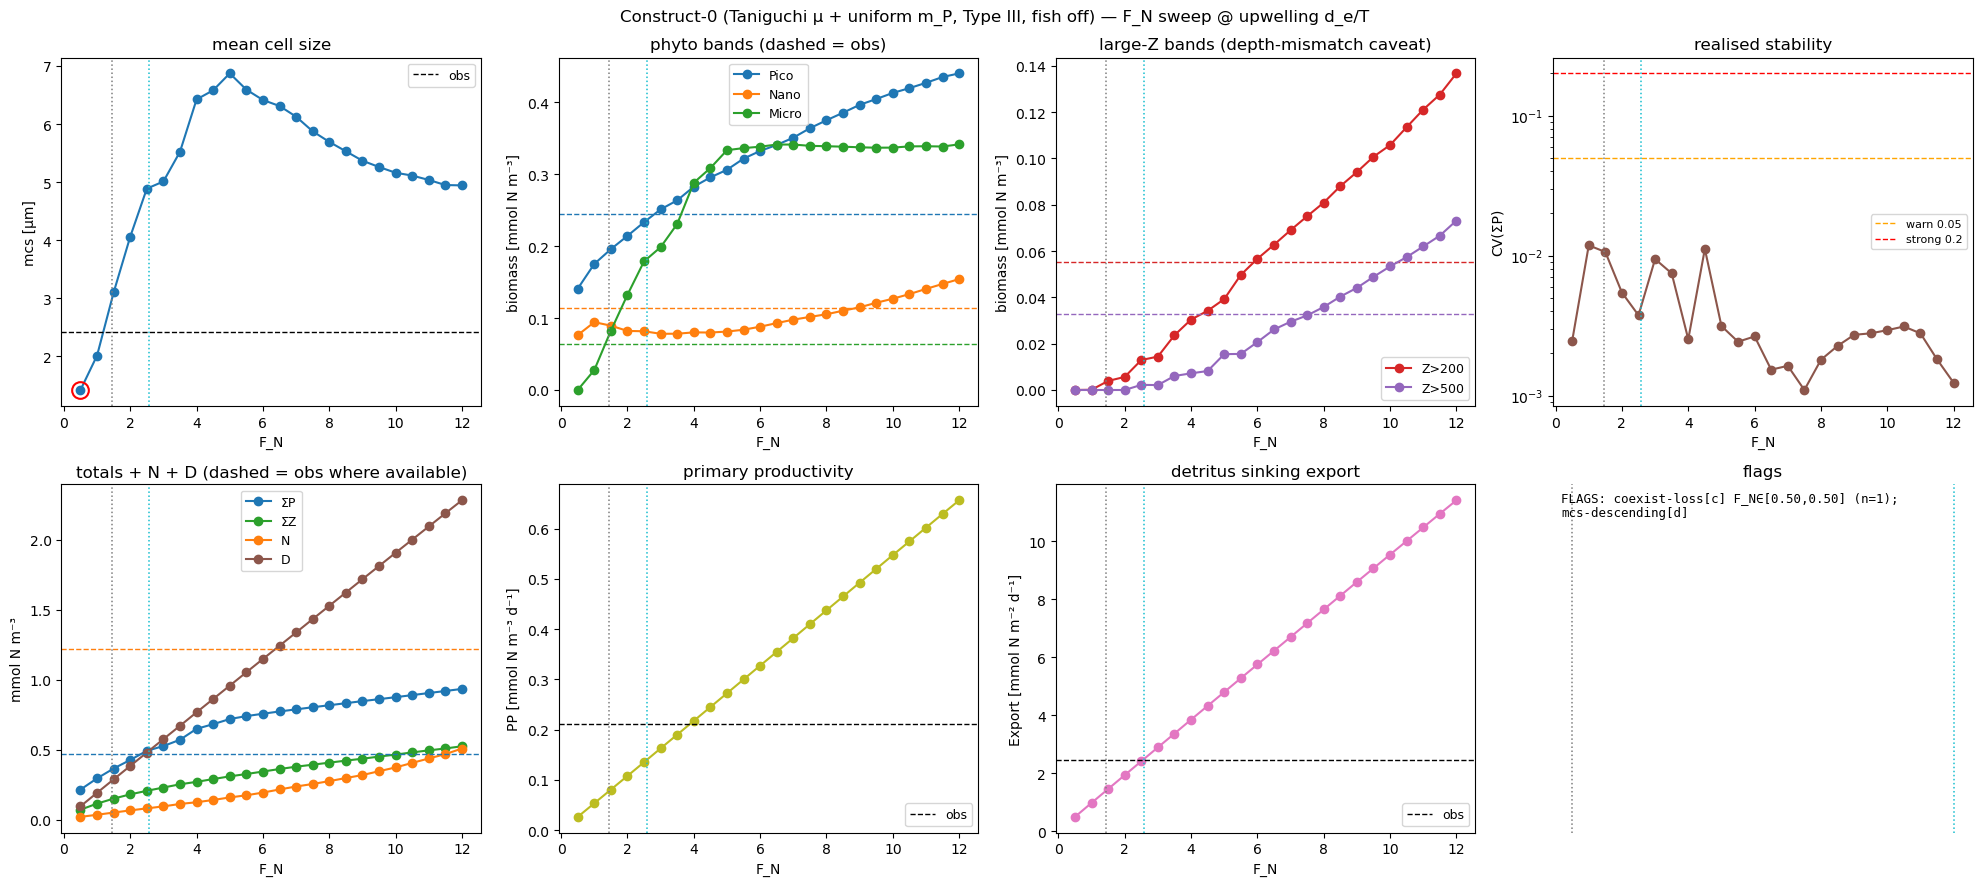

In [4]:
# ── Construct-0 fish-off F_N sweep (model_baseline) across the obs range ──────
# Validates the flag layer in the bloom regime + the Core__solver_kwargs
# runtime override. One parscan in this cell.
import importlib, json, numpy as np, matplotlib.pyplot as plt
import baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
importlib.reload(pue); importlib.reload(brs)
from xso.parscans import run_xso_parscan

# obs reference = pooled 'all' (curve-on-curve yardstick); drive = upwelling d_e/T
_, _, _, mdf_all, _      = co.load_cariaco_targets('all', months='hplc',
                                                   agg='median', include_temperature=True)
*_, forcing_up           = co.load_cariaco_targets('upwelling', months='hplc',
                                                   agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(mdf_all)

# runtime solver override: keep RK45+relaxed atol, loosen the neg floor so
# oscillatory bloom cells run to completion (→ a real CV) instead of NaN-padding
solver_kw = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}
fixed = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
fixed['Core__solver_kwargs'] = json.dumps(solver_kw)

FN_VALUES = np.linspace(0.5, 12.0, 24)

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)

m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': forcing_up['Inflow__de']})
header = "Construct-0 (Taniguchi μ + uniform m_P, Type III, fish off) — F_N sweep @ upwelling d_e/T"
pue.print_scan_table_1d(m, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(m, obs_refs, header, axis_label='F_N')
for ax in fig.axes:                                   # regime-median F_N marks
    for fn, c in [(1.45, 'C7'), (2.58, 'C9')]:
        ax.axvline(fn, color=c, ls=':', lw=1.1)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_baseline_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 24 points using 8 workers...
1D Scan complete. Time taken: 31.10725 seconds.

=== Taniguchi μ + Banas m_P=0.1·μ, Type III, fish off — F_N sweep @ upwelling ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp      CV  flag
 0.500   0.63   0.099   0.000   0.000   0.099  0.0000  0.0000   0.043   0.033   0.099   0.025   0.496  0.0017     c
 1.391   0.68   0.158   0.006   0.000   0.163  0.0000  0.0000   0.117   0.065   0.272   0.072   1.362  0.0063     c
 2.283   0.79   0.201   0.021   0.000   0.222  0.0000  0.0000   0.165   0.089   0.445   0.120   2.224  0.0010     c
 3.174   0.94   0.236   0.050   0.000   0.287  0.0004  0.00

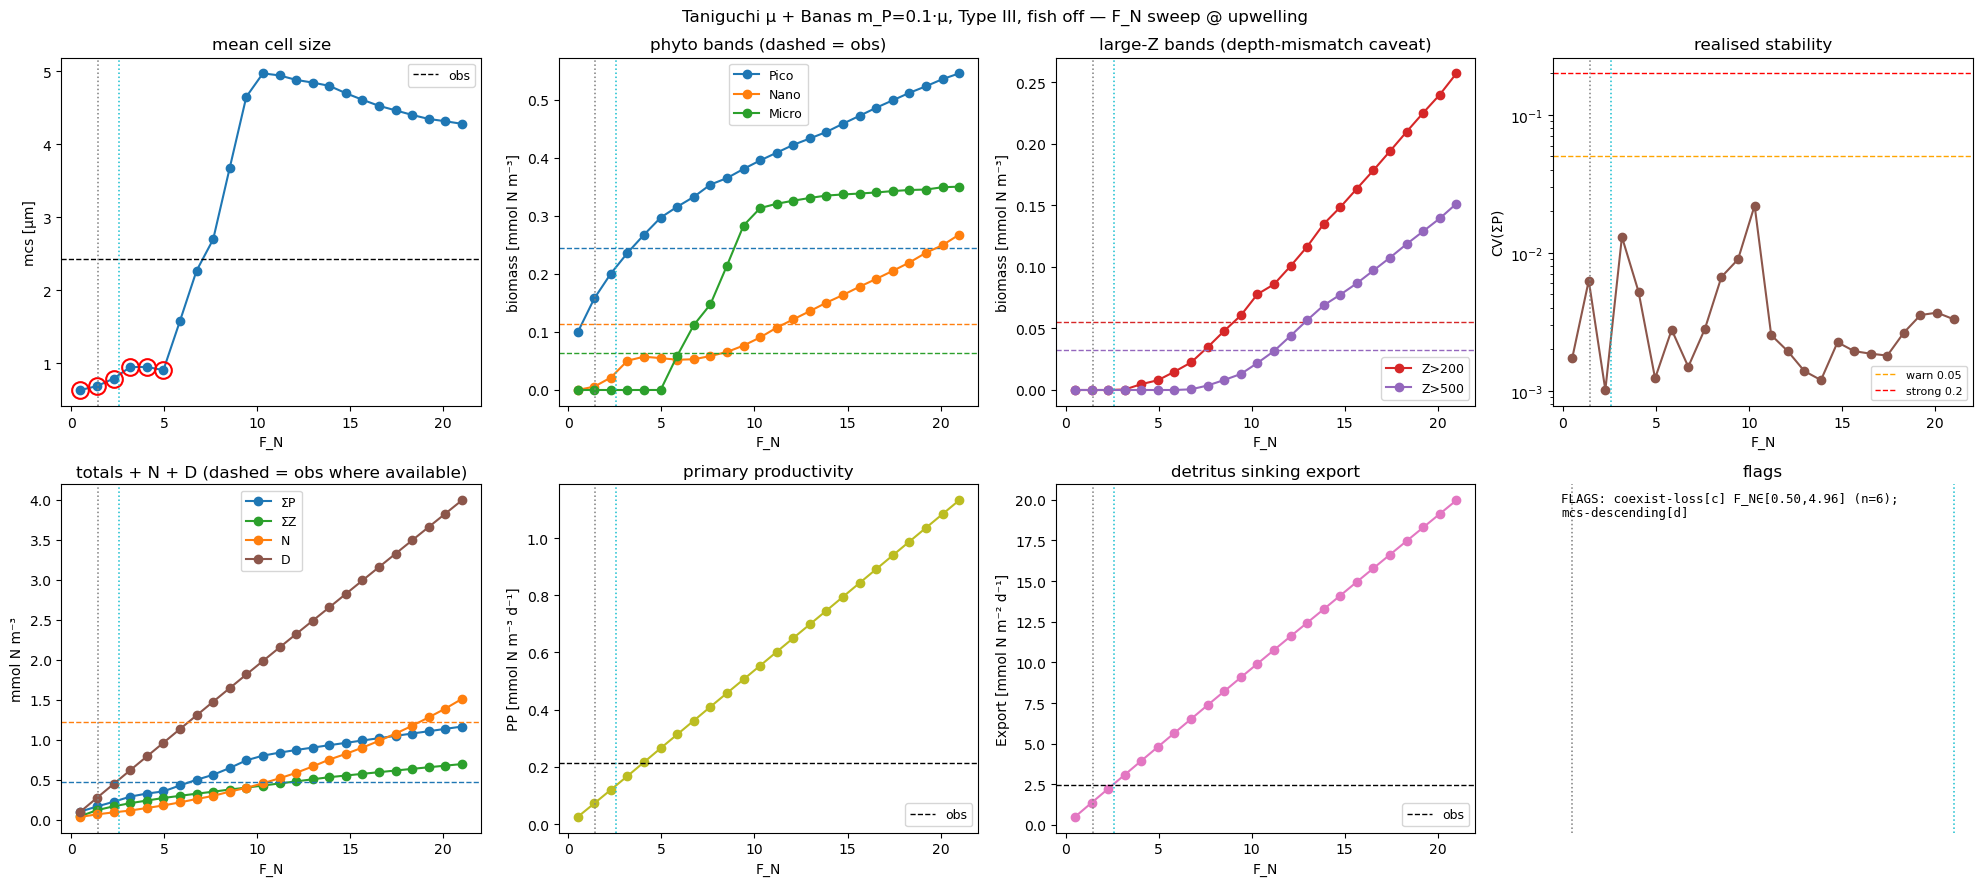

In [6]:
# ── Taniguchi μ + Banas size-scaled m_P (0.1·μ), Type III, fish off — F_N sweep ──
# Tests the documented descending-limb fix. Watch the d (descending) flag + the
# admissibility flags (c/X) for the 0.2 µm-floor crash the 2026-06-14 note warned of.
import importlib, json, numpy as np, matplotlib.pyplot as plt
import baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
importlib.reload(pue); importlib.reload(brs)
from xso.parscans import run_xso_parscan

_, _, _, mdf_all, _ = co.load_cariaco_targets('all', months='hplc',
                                              agg='median', include_temperature=True)
*_, forcing_up      = co.load_cariaco_targets('upwelling', months='hplc',
                                              agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(mdf_all)

esd = brs.phyto_esd
mu_tani = 1.36 * esd ** (-0.16)        # Taniguchi 2014 growth (kept)
ks_tani = 0.33 * esd ** ( 0.48)

solver_kw = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}
fixed = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
fixed.update({
    'Growth__mu_max':        mu_tani,
    'Growth__halfsat':       ks_tani,
    'PhytoMortality__coeff': 0.1,            # Banas: m_P = 0.1·μ_max (tracks Taniguchi μ)
    'Core__solver_kwargs':   json.dumps(solver_kw),
})

FN_VALUES = np.linspace(0.5, 12.0, 24)
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim',
    param_name='Inflow__FN', param_values=FN_VALUES,
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats', postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': forcing_up['Inflow__de']})
header = "Taniguchi μ + Banas m_P=0.1·μ, Type III, fish off — F_N sweep @ upwelling"
pue.print_scan_table_1d(m, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(m, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9')]:
        ax.axvline(fn, color=c, ls=':', lw=1.1)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 3 points using 8 workers...
1D Scan complete. Time taken: 11.57044 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 3 points using 8 workers...
1D Scan complete. Time taken: 9.57349 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
----------------------

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 520454 RHS evaluations for 5000 output points (104/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 534362 RHS evaluations for 5000 output points (107/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may

1D Scan complete. Time taken: 218.59668 seconds.

mcs(F_N) monotonicity — 9 curves in 7.5 min (obs mcs=2.42; non-decreasing first)
construct       KsZ non_decr maxdrop% peakFN mcs_lo mcs_hi mcs_end   maxCV  Z200hi  flags
taniguchi      0.40     True      0.0   12.0   1.10   7.68    7.68  0.0047  0.0917      c
maranon_ward   0.15     True      0.0   12.0   2.07   3.38    3.38  0.0066  0.2422      -
maranon_ward   0.25     True      0.0   12.0   1.66   3.91    3.91  0.0052  0.3413      c
maranon_ward   0.40     True      0.0   12.0   1.59   4.34    4.34  0.0115  0.2165      c
banas          0.15     True      0.0    0.5   0.63   0.63    0.63  0.0037  0.0674      c
banas          0.25     True      0.0    0.5   0.63   0.63    0.63  0.0093  0.0544      c
banas          0.40     True      0.0    0.5   0.63   0.63    0.63  0.0014  0.0358      c
taniguchi      0.15    False     19.9    6.2   1.61   4.36    3.49  0.0054  0.1816      c
taniguchi      0.25    False     21.4    6.2   1.41   6.67 

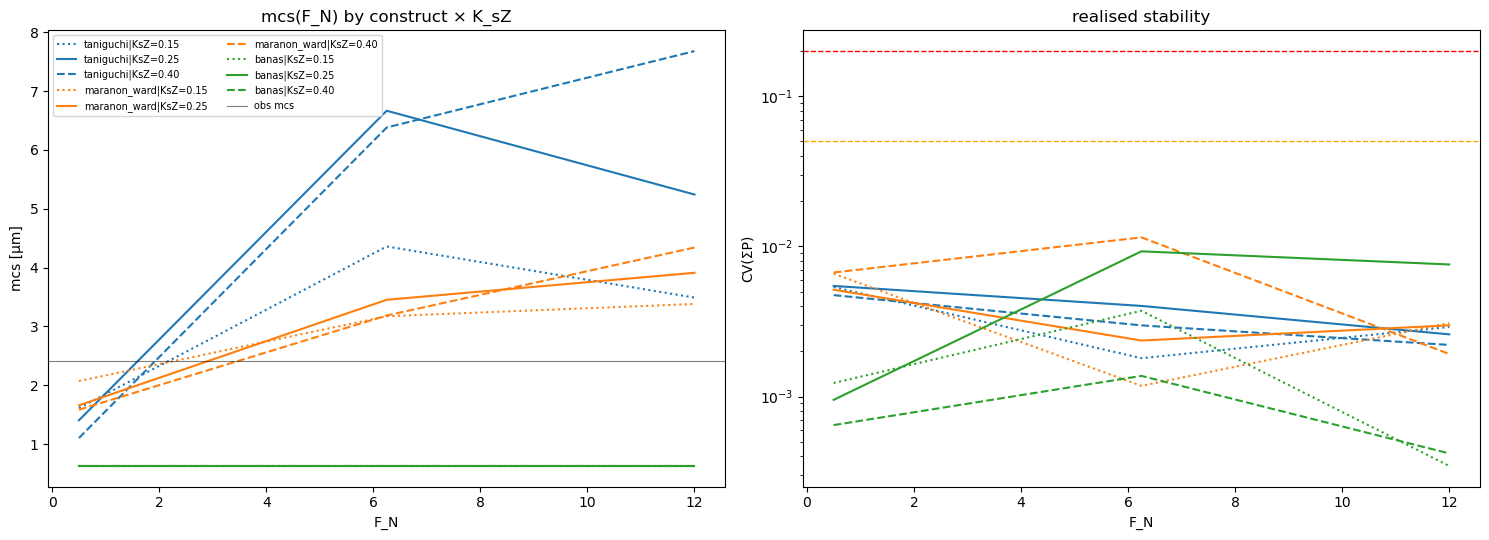


Saved night_scan_mcs_FN.nc + night_scan_mcs_FN.png


In [9]:
# ── mcs(F_N) MONOTONICITY SCAN across growth allometries — light starter ─────
# Inner (XSO parscan): F_N sweep → the mcs(F_N) curve that must stay non-decreasing
# Outer (Python loop): 3 growth constructs × 3 K_sZ = 9 curves
# Per curve: max descent, peak F_N, stability/coexist flags. Ranked, saved, plotted.
import json, time, numpy as np, xarray as xr, matplotlib.pyplot as plt
import baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
import importlib; importlib.reload(pue); importlib.reload(brs)
from xso.parscans import run_xso_parscan

*_, forcing_up    = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
_,_,_, mdf_all, _ = co.load_cariaco_targets('all',       months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(mdf_all)
de_up    = forcing_up['Inflow__de']
fixed_base = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}     # d_e + T (upwelling box)
SOLVER_KW  = json.dumps({**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3})

esd = brs.phyto_esd
CONSTRUCTS = {   # growth allometry + its native mortality form (single-source-ish)
    'taniguchi':    dict(model='model_baseline', setup='setup_baseline_slim',
                         ov={'Growth__mu_max': 1.36*esd**-0.16, 'Growth__halfsat': 0.33*esd**0.48}),
    'maranon_ward': dict(model='model_baseline', setup='setup_baseline_slim',
                         ov={'Growth__mu_max': np.where(esd<=5.38, 0.33*esd**0.57, 1.83*esd**-0.45),
                             'Growth__halfsat': 0.143*esd**0.81}),
    'banas':        dict(model='model_baseline_banas', setup='setup_baseline_banas_slim',
                         ov={'Growth__mu_max': 2.6*esd**-0.45, 'Growth__halfsat': 0.10*esd**1.0,
                             'PhytoMortality__coeff': 0.1}),
}
KSZ_VALUES = np.array([0.15, 0.25, 0.40])     # 3 points/construct (Type III window)
FN_VALUES  = np.linspace(0.5, 12.0, 3)
CURVE_KEYS = ['mcs','P_pico','P_nano','P_micro','sumP','Z_gt200','Z_gt500','N','Export','cv_sumP','tail_has_nan']

rows, curves, t0 = [], {}, time.time()
for cname, cfg in CONSTRUCTS.items():
    for ksz in KSZ_VALUES:
        fixed = {**fixed_base, **cfg['ov'], 'Grazing__KsZ': float(ksz), 'Core__solver_kwargs': SOLVER_KW}
        scan = run_xso_parscan(
            model_file_name='baseline_r0_setups',
            model_name=cfg['model'], model_setup_name=cfg['setup'],
            param_name='Inflow__FN', param_values=FN_VALUES, fixed_overrides=fixed,
            postprocess_name='avg_tail_stats', postprocess_kwargs={'avg_window': 1000}, processes=8,
        )
        m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': de_up})
        f = pue.compute_flags(m, obs_refs)
        mcs = np.asarray(m['mcs'], float)
        ok = np.isfinite(mcs).any()
        run_max = np.fmax.accumulate(np.where(np.isfinite(mcs), mcs, -np.inf))
        drop = float(np.nanmax((run_max - mcs) / np.where(run_max > 0, run_max, np.nan))) if ok else np.nan
        peak_fn = float(m['axis'][int(np.nanargmax(mcs))]) if ok else np.nan
        label = f"{cname}|KsZ={ksz:.2f}"
        rows.append(dict(construct=cname, KsZ=float(ksz), non_decr=not f['mcs_descending'],
                         max_drop=drop, peak_FN=peak_fn, mcs_lo=float(np.nanmin(mcs)) if ok else np.nan,
                         mcs_hi=float(np.nanmax(mcs)) if ok else np.nan, mcs_end=float(mcs[-1]),
                         maxCV=float(np.nanmax(m['cv_sumP'])), coexist_loss=bool(np.any(f['coexist_loss'])),
                         unstable=bool(np.any(f['unstable'])), collapse=bool(np.any(f['collapse'])),
                         Z200_hi=float(np.nanmax(m['Z_gt200']))))
        curves[label] = {k: np.asarray(m[k], float) for k in CURVE_KEYS if k in m}

combos = list(curves.keys())
ds = xr.Dataset(
    {k: (('combo','F_N'), np.vstack([curves[c].get(k, np.full(len(FN_VALUES), np.nan)) for c in combos]))
     for k in CURVE_KEYS}, coords={'combo': combos, 'F_N': FN_VALUES})
ds.to_netcdf('night_scan_mcs_FN.nc')

print(f"\n{'='*94}\nmcs(F_N) monotonicity — {len(rows)} curves in {(time.time()-t0)/60:.1f} min "
      f"(obs mcs={obs_refs['mcs']:.2f}; non-decreasing first)\n{'='*94}")
print(f"{'construct':13s}{'KsZ':>6}{'non_decr':>9}{'maxdrop%':>9}{'peakFN':>7}{'mcs_lo':>7}"
      f"{'mcs_hi':>7}{'mcs_end':>8}{'maxCV':>8}{'Z200hi':>8}{'flags':>7}")
for r in sorted(rows, key=lambda r: (not r['non_decr'], r['max_drop'])):
    fl = (('X' if r['collapse'] else '')+('U' if r['unstable'] else '')+('c' if r['coexist_loss'] else '')) or '-'
    print(f"{r['construct']:13s}{r['KsZ']:6.2f}{str(r['non_decr']):>9}{100*r['max_drop']:9.1f}{r['peak_FN']:7.1f}"
          f"{r['mcs_lo']:7.2f}{r['mcs_hi']:7.2f}{r['mcs_end']:8.2f}{r['maxCV']:8.4f}{r['Z200_hi']:8.4f}{fl:>7}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
colors = {'taniguchi':'C0','maranon_ward':'C1','banas':'C2'}; styles = {0.15:':',0.25:'-',0.40:'--'}
for c in combos:
    cn = c.split('|')[0]; kz = float(c.split('=')[1])
    ax[0].plot(FN_VALUES, ds['mcs'].sel(combo=c), color=colors[cn], ls=styles[kz], label=c)
    ax[1].plot(FN_VALUES, ds['cv_sumP'].sel(combo=c), color=colors[cn], ls=styles[kz])
ax[0].axhline(obs_refs['mcs'], color='k', lw=0.8, alpha=0.5, label='obs mcs')
ax[0].set_xlabel('F_N'); ax[0].set_ylabel('mcs [µm]'); ax[0].set_title('mcs(F_N) by construct × K_sZ'); ax[0].legend(fontsize=7, ncol=2)
ax[1].axhline(0.05, color='orange', ls='--', lw=1); ax[1].axhline(0.20, color='red', ls='--', lw=1)
ax[1].set_yscale('log'); ax[1].set_xlabel('F_N'); ax[1].set_ylabel('CV(ΣP)'); ax[1].set_title('realised stability')
plt.tight_layout(); plt.savefig('night_scan_mcs_FN.png', dpi=110); plt.show()
print("\nSaved night_scan_mcs_FN.nc + night_scan_mcs_FN.png")

MONOTONICITY SCAN v2 — 224 curves (2 growth × 4 m_P × 7 K_sZ × 4 σ), 30 F_N pts each



/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2193 on P[0] = -5.3. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   16/224 | elapsed 12.0 min | ETA 156.2 min


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1953 on P[5] = -0.00121. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3781 on P[5] = -0.274. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4990 on P[11] = -0.00137. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'ins

   32/224 | elapsed 23.6 min | ETA 141.3 min
   48/224 | elapsed 33.6 min | ETA 123.3 min


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1669 on P[5] = -0.00201. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3439 on P[9] = -2.28. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   64/224 | elapsed 44.6 min | ETA 111.6 min
   80/224 | elapsed 54.5 min | ETA 98.0 min


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3374 on P[0] = -1.49. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3277 on P[0] = -0.919. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   96/224 | elapsed 64.8 min | ETA 86.4 min
  112/224 | elapsed 74.5 min | ETA 74.5 min
  128/224 | elapsed 79.9 min | ETA 59.9 min
  144/224 | elapsed 84.8 min | ETA 47.1 min
  160/224 | elapsed 89.7 min | ETA 35.9 min
  176/224 | elapsed 94.5 min | ETA 25.8 min
  192/224 | elapsed 99.2 min | ETA 16.5 min
  208/224 | elapsed 103.9 min | ETA  8.0 min
  224/224 | elapsed 108.2 min | ETA  0.0 min

mcs(F_N) v2 — 224 curves in 108.2 min | non-decreasing & rising: 28/224 | obs mcs=2.42  (top 30)
growth            m   KsZ   sig nondec rises  drop% peakFN mcs_hi mcs_end   maxCV  Z200hi  flag
maranon_ward  0.020  0.20  0.10   True  True    2.1   12.0   3.99    3.99  0.0126  0.2916     c
maranon_ward  0.040  0.20  0.10   True  True    1.8   12.0   3.98    3.98  0.0078  0.2784     c
maranon_ward  0.040  0.35  0.15   True  True    1.6   12.0   3.94    3.94  0.0165  0.2350     c
maranon_ward  0.040  0.30  0.15   True  True    1.8   12.0   3.92    3.92  0.0154  0.2792     c
maranon_ward  0.060  0.2

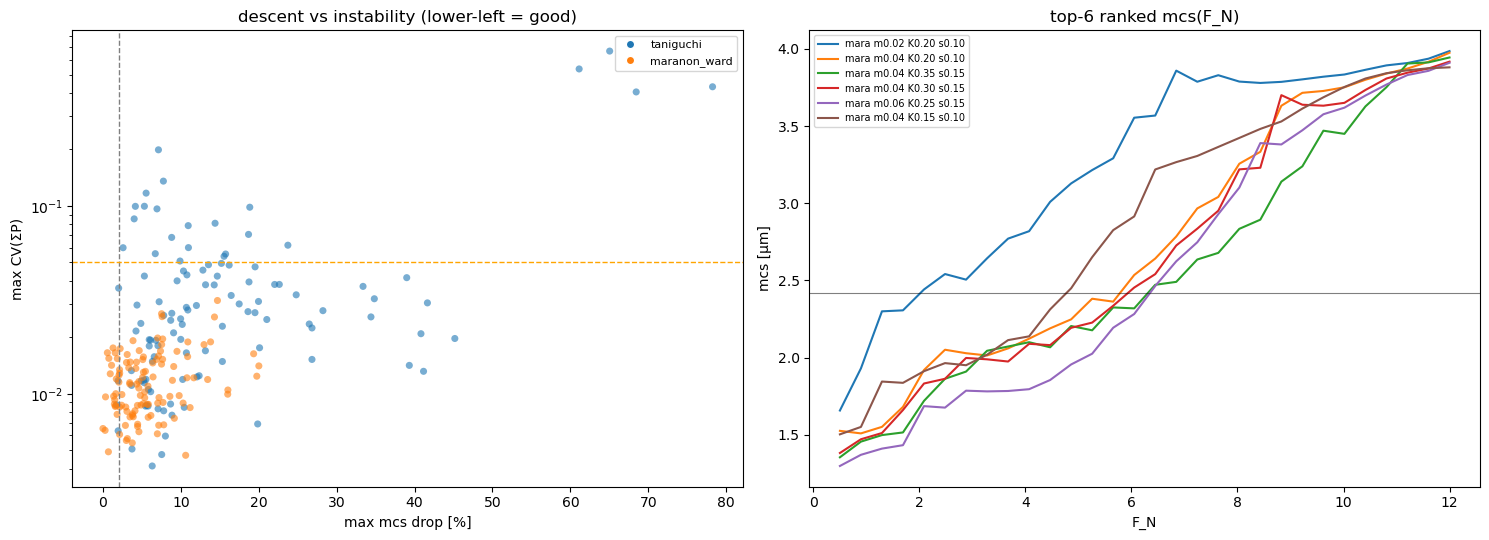


Saved night_scan_mcs_FN.nc + night_scan_mcs_FN.png


In [10]:
# ── mcs(F_N) MONOTONICITY SCAN v2 — Banas dropped, focused on the live region ─
# 2 growth (Taniguchi, Marañón+Ward) × 4 uniform-m_P × 7 K_sZ × 4 σ = 224 curves,
# F_N inner (30 pts). All model_baseline (fast); Banas growth/mort excluded (stiff+Pico).
import json, time, contextlib, io
import numpy as np, xarray as xr, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
import importlib; importlib.reload(pue); importlib.reload(brs)
from xso.parscans import run_xso_parscan

*_, forcing_up    = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
_,_,_, mdf_all, _ = co.load_cariaco_targets('all',       months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(mdf_all); de_up = forcing_up['Inflow__de']
fixed_base = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
SOLVER_KW  = json.dumps({**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3})

esd = brs.phyto_esd
GROWTH = {
    'taniguchi':    {'Growth__mu_max': 1.36*esd**-0.16, 'Growth__halfsat': 0.33*esd**0.48},
    'maranon_ward': {'Growth__mu_max': np.where(esd<=5.38, 0.33*esd**0.57, 1.83*esd**-0.45),
                     'Growth__halfsat': 0.143*esd**0.81},
}
MORT_MAG   = np.array([0.02, 0.04, 0.06, 0.10])   # uniform m_P (Ward→Dutkiewicz span)
KSZ_VALUES = np.array([0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45])
SIGMA_VALUES = np.array([0.10, 0.15, 0.20, 0.25])
FN_VALUES  = np.linspace(0.5, 12.0, 30)
CURVE_KEYS = ['mcs','P_pico','P_nano','P_micro','sumP','Z_gt200','Z_gt500','N','Export','cv_sumP','tail_has_nan']

combos_cfg = [(g, gov, float(mv), float(kz), float(sg))
              for g, gov in GROWTH.items()
              for mv in MORT_MAG for kz in KSZ_VALUES for sg in SIGMA_VALUES]
n_total = len(combos_cfg)
print(f"MONOTONICITY SCAN v2 — {n_total} curves (2 growth × {len(MORT_MAG)} m_P × "
      f"{len(KSZ_VALUES)} K_sZ × {len(SIGMA_VALUES)} σ), {len(FN_VALUES)} F_N pts each\n")

rows, curves, t0, _sink = [], {}, time.time(), io.StringIO()
for i, (g, gov, mv, kz, sg) in enumerate(combos_cfg):
    fixed = {**fixed_base, **gov, 'PhytoMortality__rate': mv, 'Grazing__KsZ': kz,
             'Grazing__sigma_log': sg, 'Core__solver_kwargs': SOLVER_KW}
    label = f"{g}|m={mv:.3f}|KsZ={kz:.2f}|s={sg:.2f}"
    try:
        with contextlib.redirect_stdout(_sink):
            scan = run_xso_parscan(
                model_file_name='baseline_r0_setups', model_name='model_baseline',
                model_setup_name='setup_baseline_slim',
                param_name='Inflow__FN', param_values=FN_VALUES, fixed_overrides=fixed,
                postprocess_name='avg_tail_stats', postprocess_kwargs={'avg_window':1000}, processes=8)
        m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': de_up})
        f = pue.compute_flags(m, obs_refs)
        mcs = np.asarray(m['mcs'], float); ok = np.isfinite(mcs).any()
        run_max = np.fmax.accumulate(np.where(np.isfinite(mcs), mcs, -np.inf))
        drop = float(np.nanmax((run_max-mcs)/np.where(run_max>0, run_max, np.nan))) if ok else np.nan
        peak = float(m['axis'][int(np.nanargmax(mcs))]) if ok else np.nan
        rng  = float(np.nanmax(mcs) - np.nanmin(mcs)) if ok else np.nan
        rows.append(dict(growth=g, m=mv, KsZ=kz, sig=sg, non_decr=not f['mcs_descending'], max_drop=drop,
                         rises=rng > 0.3, peak_FN=peak, mcs_lo=float(np.nanmin(mcs)) if ok else np.nan,
                         mcs_hi=float(np.nanmax(mcs)) if ok else np.nan, mcs_end=float(mcs[-1]),
                         maxCV=float(np.nanmax(m['cv_sumP'])), Z200hi=float(np.nanmax(m['Z_gt200'])),
                         coexist=bool(np.any(f['coexist_loss'])), unstable=bool(np.any(f['unstable'])),
                         collapse=bool(np.any(f['collapse']))))
        curves[label] = {k: np.asarray(m[k], float) for k in CURVE_KEYS if k in m}
    except Exception as e:
        rows.append(dict(growth=g, m=mv, KsZ=kz, sig=sg, non_decr=False, max_drop=np.nan, rises=False,
                         peak_FN=np.nan, mcs_lo=np.nan, mcs_hi=np.nan, mcs_end=np.nan, maxCV=np.nan,
                         Z200hi=np.nan, coexist=False, unstable=False, collapse=True))
        curves[label] = {k: np.full(len(FN_VALUES), np.nan) for k in CURVE_KEYS}
        print(f"  [warn] {label}: {e}")
    if (i+1) % 16 == 0 or (i+1) == n_total:
        cl = list(curves.keys())
        xr.Dataset({k: (('combo','F_N'),
                        np.vstack([curves[c].get(k, np.full(len(FN_VALUES),np.nan)) for c in cl]))
                    for k in CURVE_KEYS}, coords={'combo':cl, 'F_N':FN_VALUES}).to_netcdf('night_scan_mcs_FN.nc')
        el = time.time()-t0
        print(f"  {i+1:3d}/{n_total} | elapsed {el/60:4.1f} min | ETA {el/(i+1)*(n_total-i-1)/60:4.1f} min")

# ── ranked: non-decreasing AND genuinely rising AND unflagged, then highest ceiling ──
ranked = sorted(rows, key=lambda r: (not (r['non_decr'] and r['rises']),
                                     (r['collapse'] or r['unstable'] or r['coexist']),
                                     -(r['mcs_hi'] if np.isfinite(r['mcs_hi']) else -1e9)))
n_good = sum(r['non_decr'] and r['rises'] for r in rows)
print(f"\n{'='*104}\nmcs(F_N) v2 — {n_total} curves in {(time.time()-t0)/60:.1f} min | "
      f"non-decreasing & rising: {n_good}/{n_total} | obs mcs={obs_refs['mcs']:.2f}  (top 30)\n{'='*104}")
print(f"{'growth':13s}{'m':>6}{'KsZ':>6}{'sig':>6}{'nondec':>7}{'rises':>6}{'drop%':>7}{'peakFN':>7}"
      f"{'mcs_hi':>7}{'mcs_end':>8}{'maxCV':>8}{'Z200hi':>8}{'flag':>6}")
for r in ranked[:30]:
    fl = (('X' if r['collapse'] else '')+('U' if r['unstable'] else '')+('c' if r['coexist'] else '')) or '-'
    dp = 100*r['max_drop'] if np.isfinite(r['max_drop']) else np.nan
    print(f"{r['growth']:13s}{r['m']:6.3f}{r['KsZ']:6.2f}{r['sig']:6.2f}{str(r['non_decr']):>7}{str(r['rises']):>6}"
          f"{dp:7.1f}{r['peak_FN']:7.1f}{r['mcs_hi']:7.2f}{r['mcs_end']:8.2f}{r['maxCV']:8.4f}{r['Z200hi']:8.4f}{fl:>6}")

# ── overview: descent-vs-instability scatter + top-6 curves ──────────────────
ds = xr.open_dataset('night_scan_mcs_FN.nc')
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
cols = {'taniguchi':'C0','maranon_ward':'C1'}
for r in rows:
    if np.isfinite(r['max_drop']) and np.isfinite(r['maxCV']):
        ax[0].scatter(100*r['max_drop'], max(r['maxCV'],1e-4), c=cols[r['growth']],
                      s=26, alpha=0.6, edgecolors='none')
ax[0].axvline(2, color='grey', ls='--', lw=1); ax[0].axhline(0.05, color='orange', ls='--', lw=1)
ax[0].set_xlabel('max mcs drop [%]'); ax[0].set_ylabel('max CV(ΣP)'); ax[0].set_yscale('log')
ax[0].set_title('descent vs instability (lower-left = good)')
ax[0].legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=cols[g],label=g) for g in cols], fontsize=8)
for r in ranked[:6]:
    lab = f"{r['growth']}|m={r['m']:.3f}|KsZ={r['KsZ']:.2f}|s={r['sig']:.2f}"
    ax[1].plot(FN_VALUES, ds['mcs'].sel(combo=lab),
               label=f"{r['growth'][:4]} m{r['m']:.2f} K{r['KsZ']:.2f} s{r['sig']:.2f}")
ax[1].axhline(obs_refs['mcs'], color='k', lw=0.8, alpha=0.5)
ax[1].set_xlabel('F_N'); ax[1].set_ylabel('mcs [µm]'); ax[1].set_title('top-6 ranked mcs(F_N)'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig('night_scan_mcs_FN.png', dpi=110); plt.show()
print("\nSaved night_scan_mcs_FN.nc + night_scan_mcs_FN.png")

obs fractions Pico/Nano/Micro = 0.58/0.27/0.15  (pooled)
monotonic+rising: 28 | nano-dominant somewhere: 0 | Micro-dominant at high F_N: 0

combo                                     domHi pico_hi nano_hi micro_hi nanoDom mcs_hi
taniguchi|m=0.100|KsZ=0.15|s=0.15          Pico    0.62    0.13     0.25   False   3.38
maranon_ward|m=0.020|KsZ=0.20|s=0.10       Pico    0.46    0.29     0.25   False   3.99
taniguchi|m=0.100|KsZ=0.20|s=0.25          Pico    0.64    0.14     0.22   False   2.87
maranon_ward|m=0.040|KsZ=0.30|s=0.15       Pico    0.50    0.29     0.22   False   3.92
maranon_ward|m=0.040|KsZ=0.20|s=0.10       Pico    0.49    0.30     0.22   False   3.98
maranon_ward|m=0.040|KsZ=0.15|s=0.10       Pico    0.46    0.33     0.21   False   3.88
maranon_ward|m=0.040|KsZ=0.35|s=0.15       Pico    0.51    0.28     0.21   False   3.94
maranon_ward|m=0.060|KsZ=0.15|s=0.10       Pico    0.47    0.33     0.20   False   3.86
maranon_ward|m=0.060|KsZ=0.25|s=0.15       Pico    0.49    0.31     

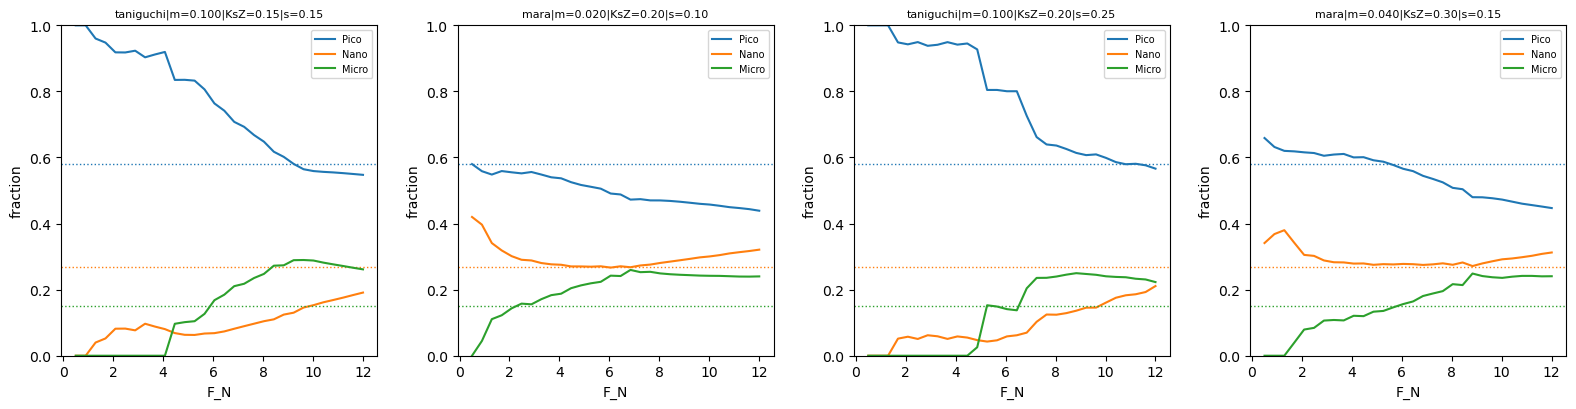

In [12]:
# ── COMPOSITION CHECK — is the monotonic mcs masking Nano-dominance? ──────────
# Reads the saved scan file (no re-run); recomputes flags incl the new nano_dominant.
import numpy as np, xarray as xr, matplotlib.pyplot as plt
import importlib, parscan_utils_extended as pue, cariaco_obs as co
importlib.reload(pue)
ds = xr.open_dataset('night_scan_mcs_FN.nc'); FN = ds['F_N'].values
_,_,_, mdf_all, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
obs = pue.build_obs_refs(mdf_all)
obs_fr = np.array([obs['P_pico'], obs['P_nano'], obs['P_micro']]); obs_fr = obs_fr/obs_fr.sum()
hi = FN >= 6.0                      # the Micro-target (high-F_N) end

rows = []
for c in ds['combo'].values:
    m = {'axis': FN}
    for k in ['mcs','P_pico','P_nano','P_micro','sumP','N','Z_gt200','Z_gt500','cv_sumP','tail_has_nan']:
        m[k] = ds[k].sel(combo=c).values
    f = pue.compute_flags(m, obs)
    mcs = m['mcs']; ok = np.isfinite(mcs).any()
    rng = (np.nanmax(mcs)-np.nanmin(mcs)) if ok else np.nan
    bins = np.vstack([m['P_pico'], m['P_nano'], m['P_micro']])
    frac = bins / np.where(bins.sum(0) > 0, bins.sum(0), np.nan)
    mean_fr_hi = np.nanmean(frac[:, hi], axis=1) if hi.any() else np.full(3, np.nan)
    dom_hi = ['Pico','Nano','Micro'][int(np.nanargmax(mean_fr_hi))] if np.isfinite(mean_fr_hi).any() else '?'
    rows.append(dict(combo=c, growth=c.split('|')[0], non_decr=not f['mcs_descending'], rises=rng > 0.3,
                     nano_dom=bool(np.any(f['nano_dominant'])), dom_hi=dom_hi,
                     micro_hi=float(np.nanmean(frac[2, hi])), nano_hi=float(np.nanmean(frac[1, hi])),
                     pico_hi=float(np.nanmean(frac[0, hi])), mcs_hi=float(np.nanmax(mcs)) if ok else np.nan))

cand = sorted([r for r in rows if r['non_decr'] and r['rises']], key=lambda r: -r['micro_hi'])
print(f"obs fractions Pico/Nano/Micro = {obs_fr[0]:.2f}/{obs_fr[1]:.2f}/{obs_fr[2]:.2f}  (pooled)")
print(f"monotonic+rising: {len(cand)} | nano-dominant somewhere: {sum(r['nano_dom'] for r in cand)} "
      f"| Micro-dominant at high F_N: {sum(r['dom_hi']=='Micro' for r in cand)}\n")
print(f"{'combo':40s}{'domHi':>7}{'pico_hi':>8}{'nano_hi':>8}{'micro_hi':>9}{'nanoDom':>8}{'mcs_hi':>7}")
for r in cand[:18]:
    print(f"{r['combo']:40s}{r['dom_hi']:>7}{r['pico_hi']:>8.2f}{r['nano_hi']:>8.2f}"
          f"{r['micro_hi']:>9.2f}{str(r['nano_dom']):>8}{r['mcs_hi']:>7.2f}")

k = min(4, len(cand))
fig, axes = plt.subplots(1, k, figsize=(4*k, 4.2), squeeze=False)
for ax, r in zip(axes[0], cand[:k]):
    tot = sum(ds[v].sel(combo=r['combo']).values for v in ['P_pico','P_nano','P_micro'])
    for bi,(lab,col,v) in enumerate([('Pico','C0','P_pico'),('Nano','C1','P_nano'),('Micro','C2','P_micro')]):
        ax.plot(FN, ds[v].sel(combo=r['combo']).values/np.where(tot>0,tot,np.nan), color=col, label=lab)
        ax.axhline(obs_fr[bi], color=col, ls=':', lw=1)
    ax.set_title(r['combo'].replace('maranon_ward','mara'), fontsize=8)
    ax.set_xlabel('F_N'); ax.set_ylabel('fraction'); ax.set_ylim(0,1); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

n months = 88; F_N 0.39–10.79 (median 1.75)
  d_e (depth_cutoff)    : r=-0.68  fit ≈ 55.89 -3.966·F_N   range 19.2–69.1
  T (Temp_C)            : r=-0.44  fit ≈ 25.64 -0.414·F_N   range 22.1–29.1

       F_N bin   n  medFN   d_e     T   Pico   Nano  Micro  dom
  0.39- 1.17  15   0.90    52  26.1   0.66   0.25   0.08   Pi
  1.17- 1.43  14   1.30    51  25.3   0.57   0.27   0.11   Pi
  1.43- 1.75  15   1.55    53  25.3   0.56   0.28   0.12   Pi
  1.75- 2.13  14   1.91    50  24.5   0.56   0.26   0.16   Pi
  2.13- 3.53  15   2.62    44  23.9   0.51   0.24   0.16   Pi
  3.53-10.79  15   4.36    33  23.6   0.23   0.17   0.62   Mi

Micro is the largest bin in 19/88 months | max monthly Micro frac 0.90
coverage  F_N>5: 4   F_N>8: 1   F_N>10: 1


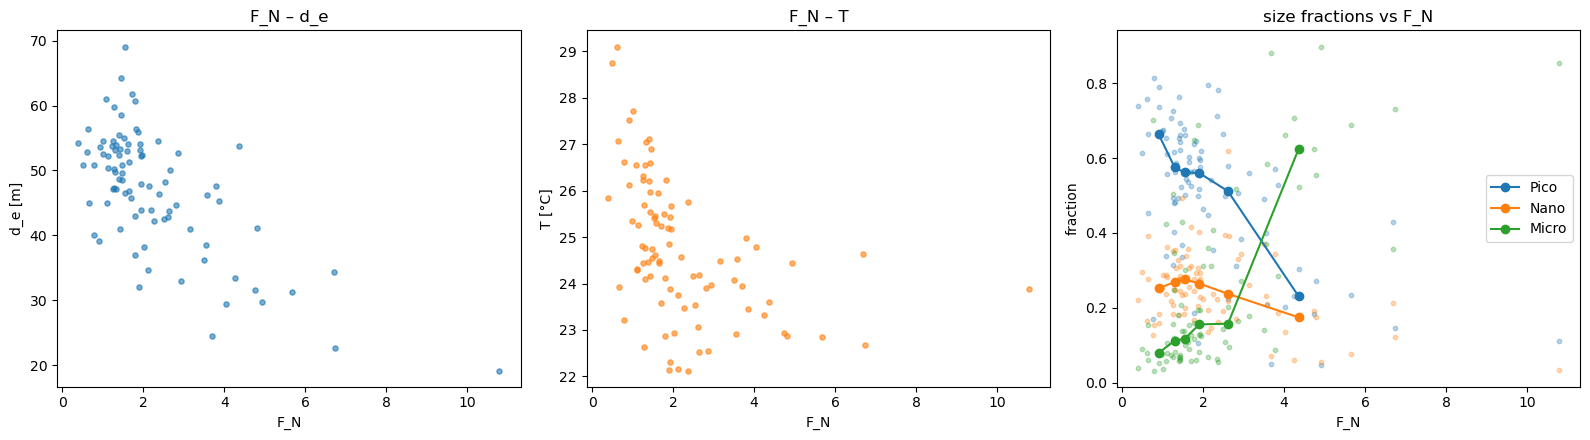

In [13]:
# ── OBS-ONLY: F_N–d_e–T forcing relationships + size fractions vs F_N ─────────
import numpy as np, matplotlib.pyplot as plt
import cariaco_obs as co
_,_,_, mdf, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
fn = mdf['FN_mmolN_m2_d'].to_numpy(float)
de = mdf['depth_cutoff'].to_numpy(float)
T  = mdf['Temp_C'].to_numpy(float)
P  = mdf[['pico_mmolN','nano_mmolN','micro_mmolN']].to_numpy(float)
fr = P / P.sum(1, keepdims=True)
ok = np.isfinite(fn)&np.isfinite(de)&np.isfinite(T)&np.isfinite(fr).all(1)
fn,de,T,fr = fn[ok],de[ok],T[ok],fr[ok]
print(f"n months = {len(fn)}; F_N {fn.min():.2f}–{fn.max():.2f} (median {np.median(fn):.2f})")
for name, y in [('d_e (depth_cutoff)', de), ('T (Temp_C)', T)]:
    b, a = np.polyfit(fn, y, 1); r = np.corrcoef(fn, y)[0,1]
    print(f"  {name:22s}: r={r:+.2f}  fit ≈ {a:.2f} {b:+.3f}·F_N   range {y.min():.1f}–{y.max():.1f}")
edges = np.quantile(fn, np.linspace(0,1,7))
print(f"\n{'F_N bin':>14}{'n':>4}{'medFN':>7}{'d_e':>6}{'T':>6}{'Pico':>7}{'Nano':>7}{'Micro':>7}{'dom':>5}")
for i in range(6):
    lo,hi = edges[i],edges[i+1]; m = (fn>=lo)&(fn<=hi) if i==5 else (fn>=lo)&(fn<hi)
    if m.sum():
        f3 = np.median(fr[m],0); dom = ['Pi','Na','Mi'][int(f3.argmax())]
        print(f"{lo:6.2f}-{hi:5.2f}{int(m.sum()):>4}{np.median(fn[m]):>7.2f}{np.median(de[m]):>6.0f}"
              f"{np.median(T[m]):>6.1f}{f3[0]:>7.2f}{f3[1]:>7.2f}{f3[2]:>7.2f}{dom:>5}")
print(f"\nMicro is the largest bin in {(fr.argmax(1)==2).sum()}/{len(fn)} months | max monthly Micro frac {fr[:,2].max():.2f}")
print(f"coverage  F_N>5: {(fn>5).sum()}   F_N>8: {(fn>8).sum()}   F_N>10: {(fn>10).sum()}")

fig, ax = plt.subplots(1,3, figsize=(16,4.5))
ax[0].scatter(fn, de, s=14, alpha=0.6); ax[0].set_xlabel('F_N'); ax[0].set_ylabel('d_e [m]'); ax[0].set_title('F_N – d_e')
ax[1].scatter(fn, T, s=14, alpha=0.6, c='C1'); ax[1].set_xlabel('F_N'); ax[1].set_ylabel('T [°C]'); ax[1].set_title('F_N – T')
for bi,(lab,cl) in enumerate([('Pico','C0'),('Nano','C1'),('Micro','C2')]):
    ax[2].scatter(fn, fr[:,bi], s=10, alpha=0.3, c=cl)
    cen,med = [],[]
    for i in range(6):
        lo,hi=edges[i],edges[i+1]; m=(fn>=lo)&(fn<=hi) if i==5 else (fn>=lo)&(fn<hi)
        if m.sum(): cen.append(np.median(fn[m])); med.append(np.median(fr[m,bi]))
    ax[2].plot(cen, med, '-o', c=cl, label=lab)
ax[2].set_xlabel('F_N'); ax[2].set_ylabel('fraction'); ax[2].set_title('size fractions vs F_N'); ax[2].legend()
plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail_stats'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 24 points using 4 workers...
1D Scan complete. Time taken: 28.23206 seconds.
F_N : [ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12. ]
d_e : [53.9 51.9 49.9 48.  46.  44.  42.  40.  38.  36.1 34.1 32.1 30.1 28.1
 26.1 24.2 22.2 20.2 19.  19.  19.  19.  19.  19. ]  expected [53.9 51.9 49.9 48.  46.  44.  42.  40.  38.  36.1 34.1 32.1 30.1 28.1
 26.1 24.2 22.2 20.2 19.  19.  19.  19.  19.  19. ]
T   : [25.43 25.23 25.02 24.81 24.6  24.4  24.19 23.98 23.78 23.57 23.36 23.16
 22.95 22.74 22.54 22.33 22.12 22.   22.   22.   22.   22.   22.   22.  ]  expected [25.43 25.23 25.02 24.81 24.6  24.4  24.19 23.98 23.78 23.57 23.3

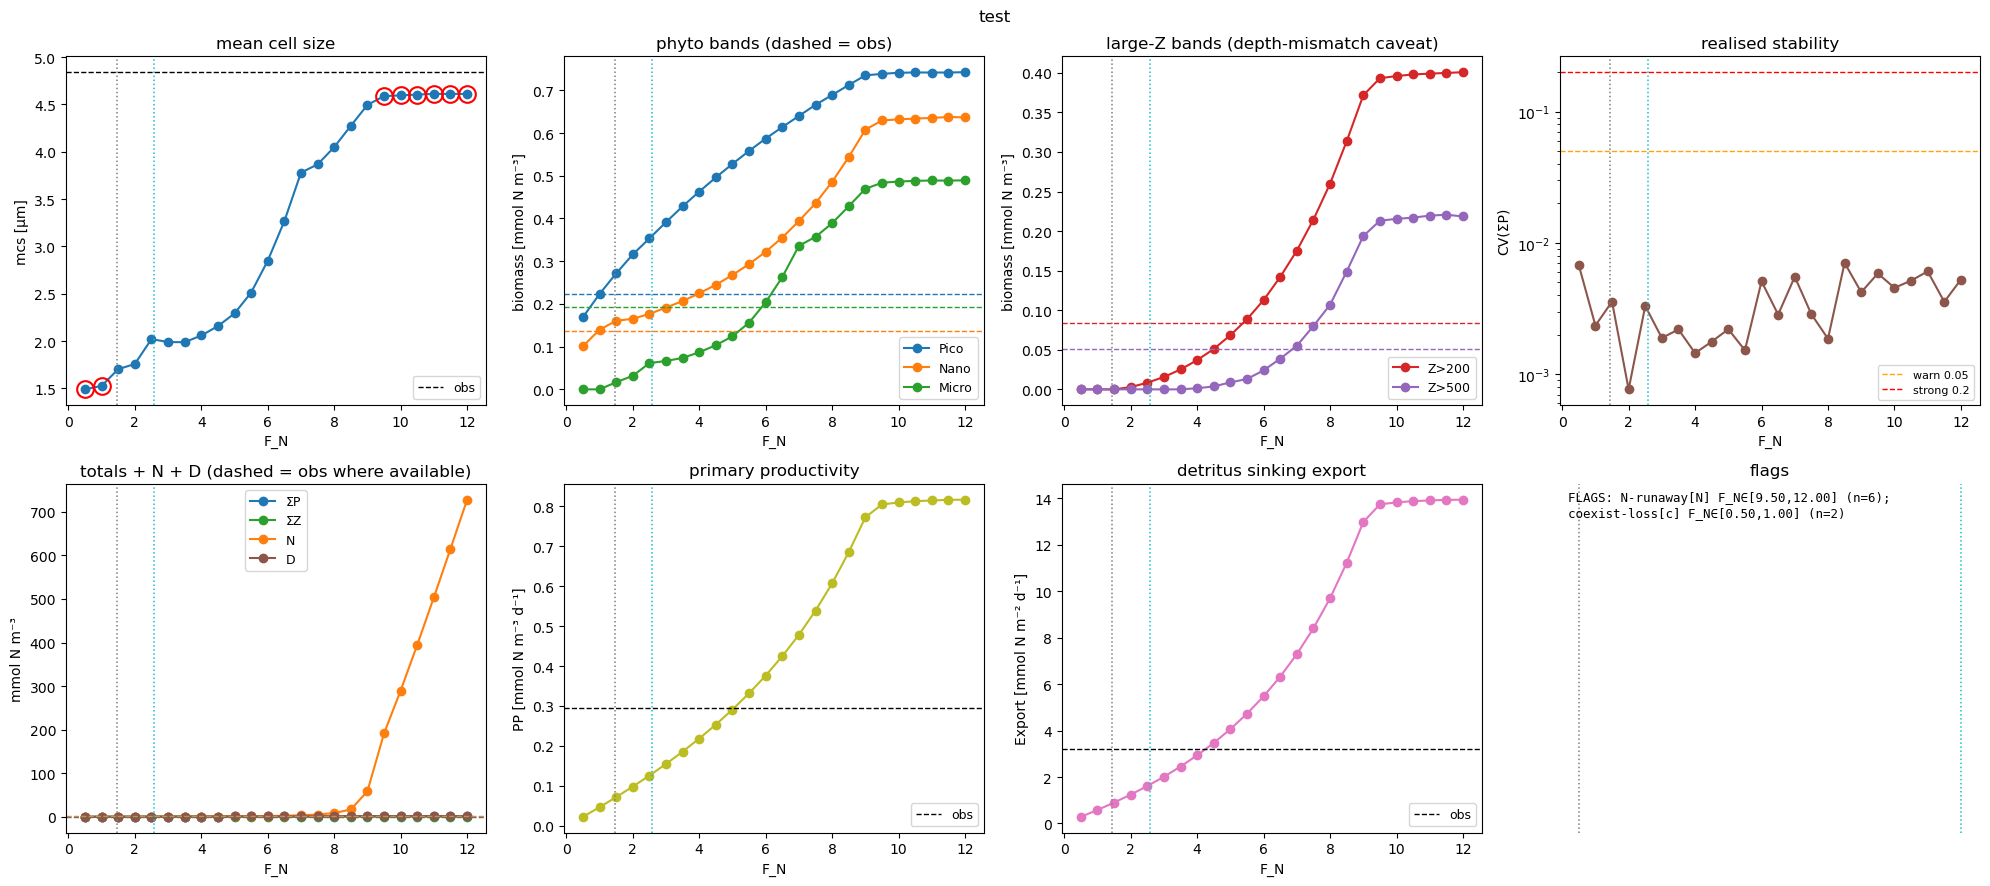

In [8]:
# ── SMOKE TEST — linked_overrides round-trip (1 candidate, 4 F_N points) ──────
import json, numpy as np
import importlib, baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
importlib.reload(pue); importlib.reload(brs)
from xso.parscans import run_xso_parscan

_,_,_, mdf_all, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
obs = pue.build_obs_refs(mdf_all); ofc = pue.build_obs_fraction_curve(mdf_all)
esd = brs.phyto_esd

FN = np.linspace(0.5, 12.0, 24)
de = np.clip(55.89 - 3.966*FN, 19.0, 69.0)
T  = np.clip(25.64 - 0.414*FN, 22.0, 29.0)
fixed = {
    'Growth__mu_max':  np.where(esd<=5.38, 0.33*esd**0.57, 1.83*esd**-0.45),  # Marañón
    'Growth__halfsat': 0.143*esd**0.81,                                       # Ward
    'PhytoMortality__rate': 0.04, 'Grazing__KsZ': 0.20, 'Grazing__sigma_log': 0.10,
    'Core__solver_kwargs': json.dumps({**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}),
}
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name='Inflow__FN', param_values=FN,
    linked_overrides={'Inflow__de': de, 'Temperature__value': T},
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats', postprocess_kwargs={'avg_window': 1000}, processes=4,
)
order = np.argsort(scan['Inflow__FN'].values)
print("F_N :", np.round(scan['Inflow__FN'].values[order], 2))
print("d_e :", np.round(scan['Inflow__de'].values[order], 1), " expected", np.round(de, 1))
print("T   :", np.round(scan['Temperature__value'].values[order], 2), " expected", np.round(T, 2))

# export uses a single d_e here (the per-point-d_e patch is deferred), so Exp is approximate:
m = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': float(np.median(de))})
pue.print_scan_table_1d(m, obs, "SMOKE — linked gradient (4 pts)", axis_label='F_N', obs_frac_curve=ofc)

fig = pue.plot_scan_panels_1d(m, obs_refs, "test", axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9')]:
        ax.axvline(fn, color=c, ls=':', lw=1.1)
plt.show()

[maranon_ward] 112 combos over ['PhytoMortality__rate', 'Grazing__KsZ', 'Grazing__sigma_log'], 30 F_N pts | gate≤8  score≤5


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=224.2 on P[23] = -0.00118. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   14/112 |  5.2 min | ETA 36.7 min
   28/112 | 10.2 min | ETA 30.6 min
   42/112 | 14.9 min | ETA 24.8 min
   56/112 | 19.4 min | ETA 19.4 min
   70/112 | 24.1 min | ETA 14.5 min
   84/112 | 28.7 min | ETA  9.6 min
   98/112 | 33.5 min | ETA  4.8 min
  112/112 | 37.9 min | ETA  0.0 min
[maranon_ward] saved curves -> scan_maranon_ward.nc

=== [maranon_ward] view='combined' — top 20 of 112 (ext=5, other=0.5) ===
obs: mcs=2.42  N=1.22  ΣP=0.47
params                              fit   pen   comb mcs_hi       P/N/M@gate   maxN  maxΣP  flags
rate=0.02|KsZ=0.2|sigma_log=0.2   0.707  2.50  2.476   3.46   0.46/0.36/0.18 457.66   0.85  N-runaway,descending,microA-fail,nanoB-fail,micro-short
rate=0.02|KsZ=0.15|sigma_log=0.15  0.720  2.50  2.519   3.52   0.44/0.37/0.18 462.84   0.84  N-runaway,descending,microA-fail,nanoB-fail,micro-short
rate=0.02|KsZ=0.15|sigma_log=0.1  0.494  7.00  3.955   4.13   0.43/0.35/0.22  46.08   1.27  extinction,descending,microA-fail,nanoB-fail,micro-short
rate=0.02|

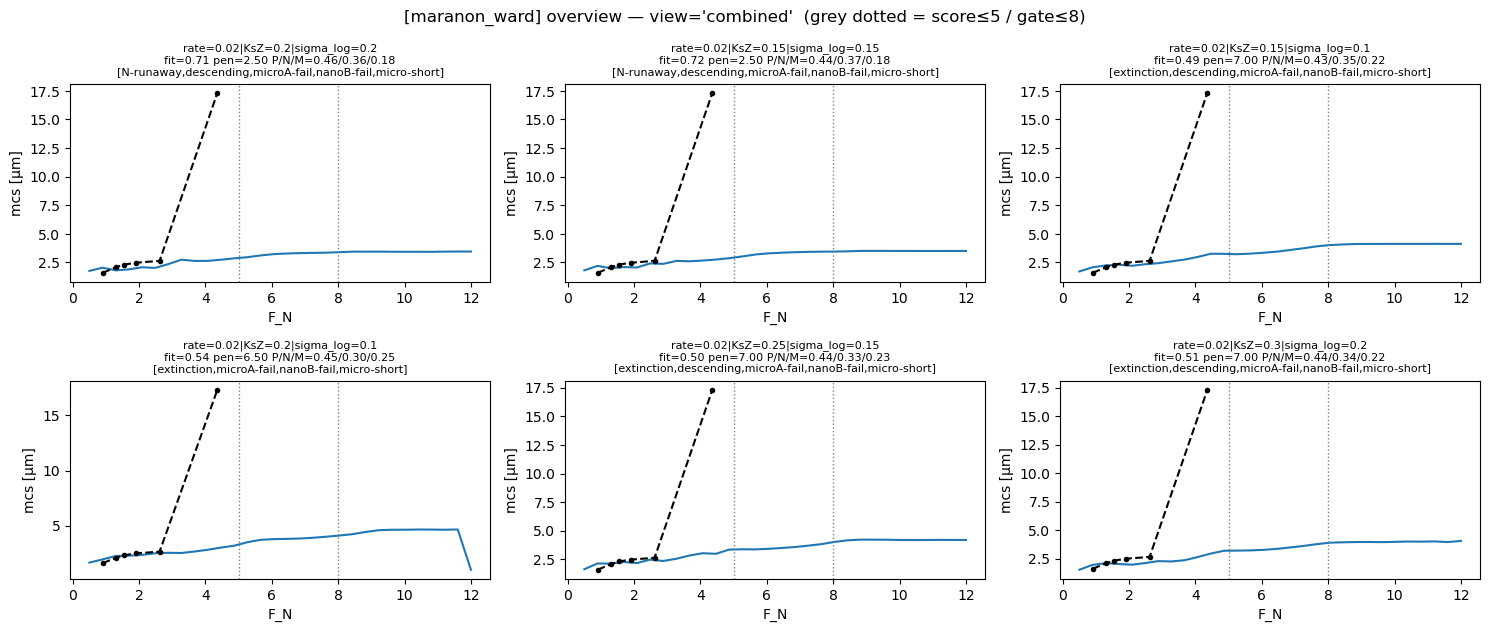

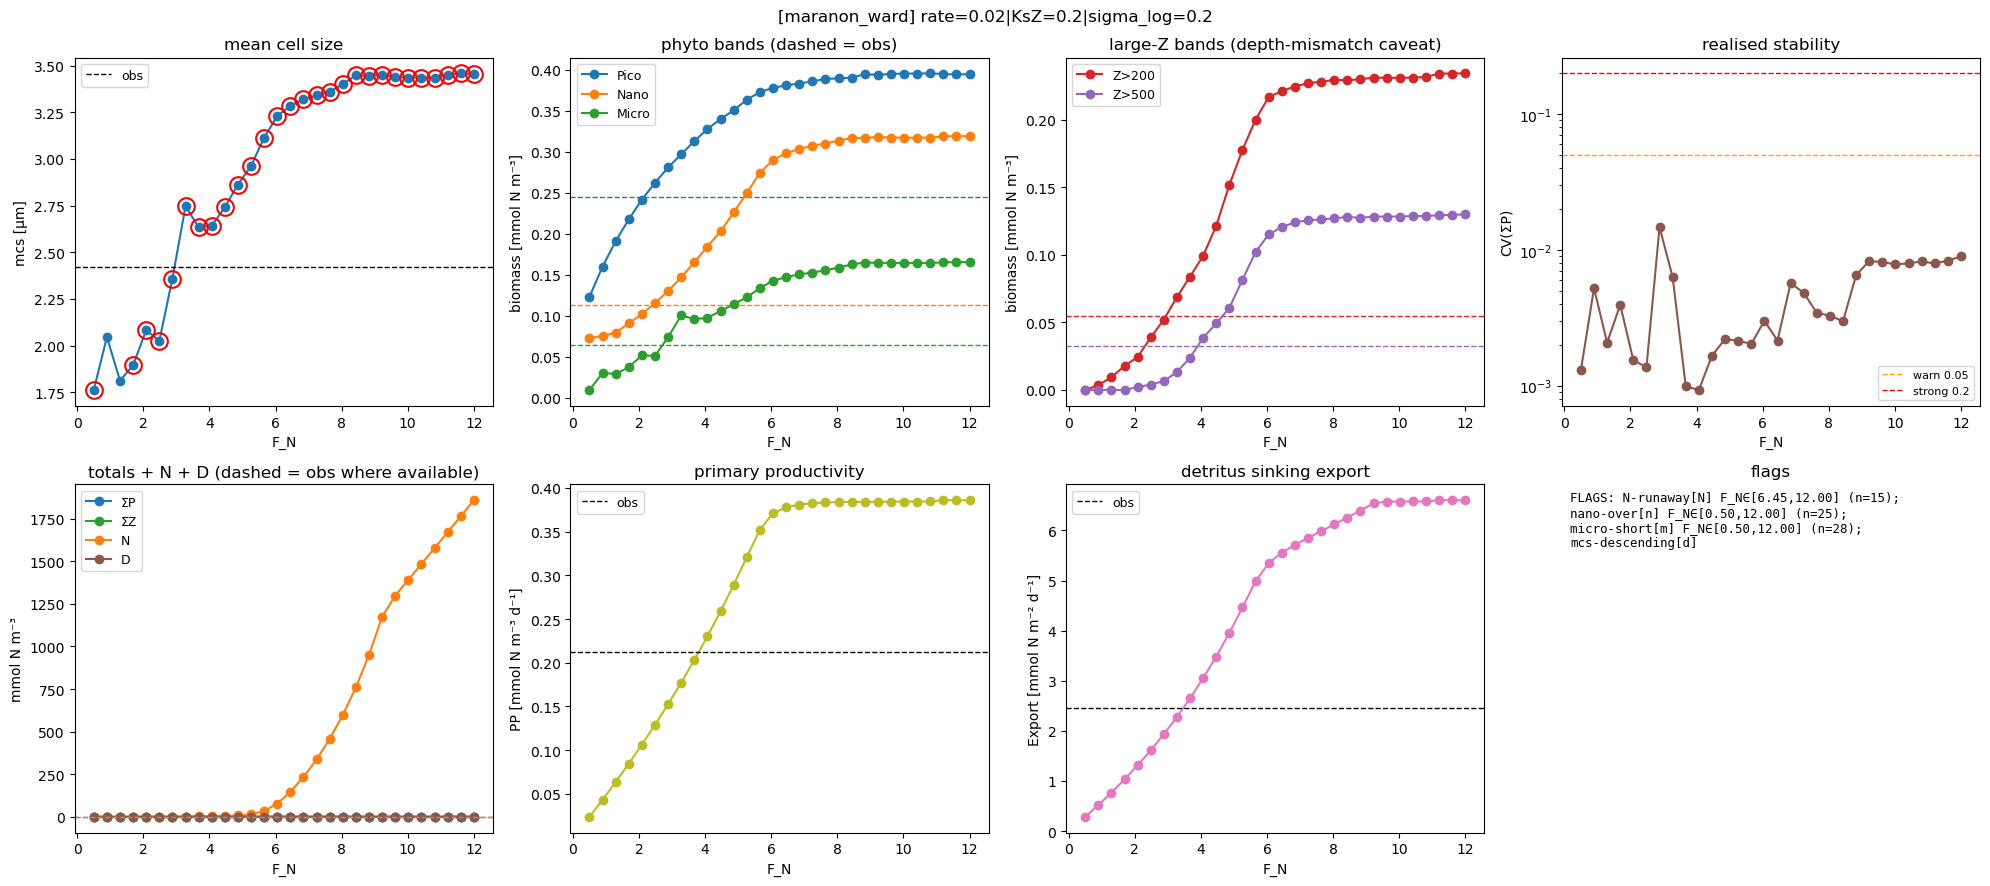

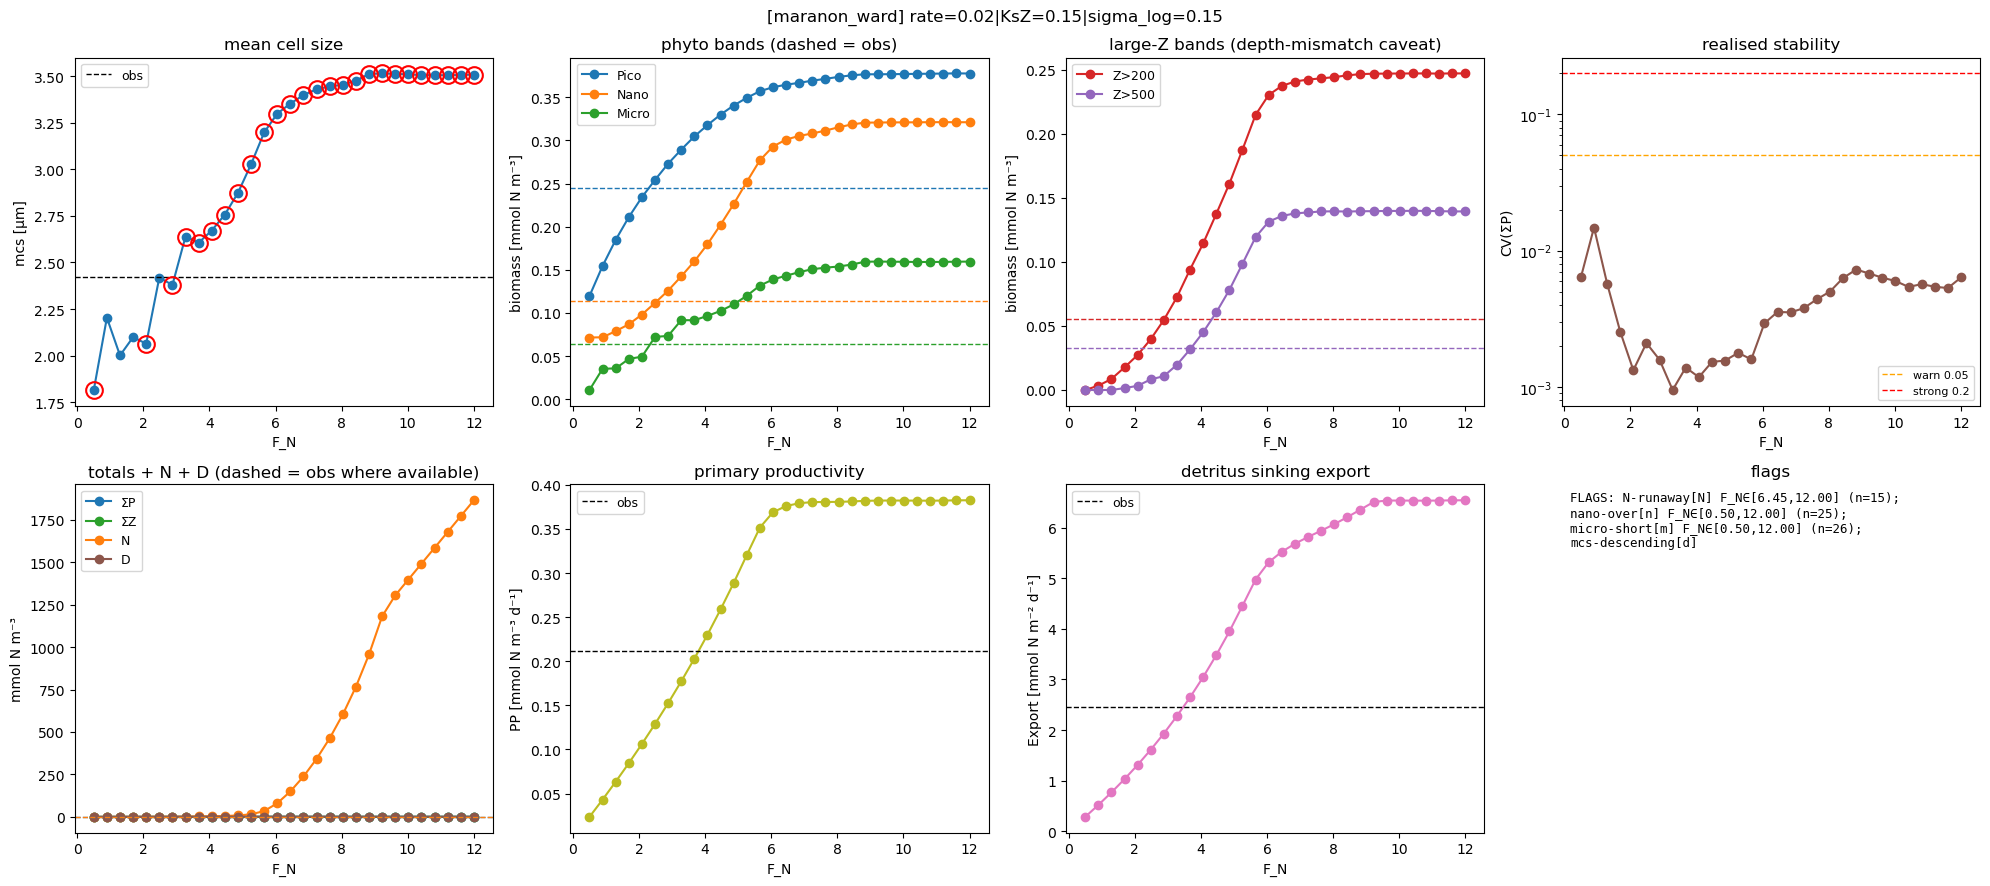

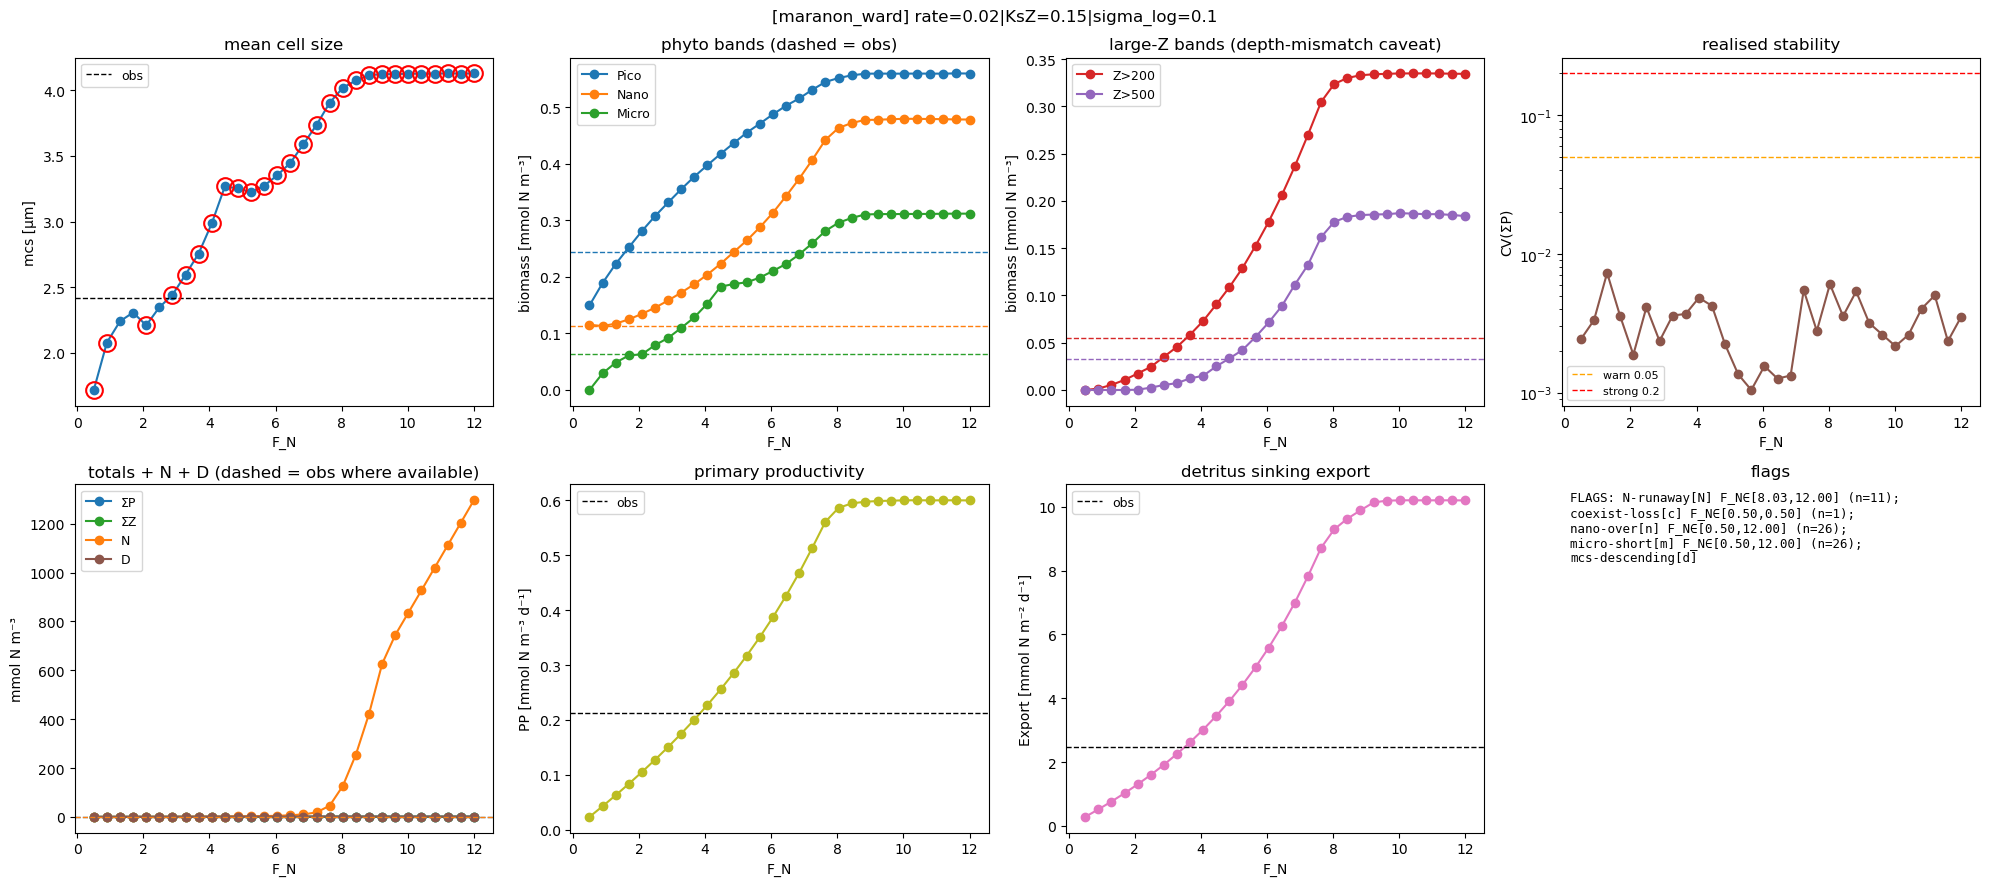

In [9]:

# ── DRIVER: gradient fit scan via the reusable harness ───────────────────────
import numpy as np
import baseline_r0_setups as brs, cariaco_obs as co, parscan_utils_extended as pue
import gradient_scan_harness as gsh
import importlib; importlib.reload(pue); importlib.reload(brs); importlib.reload(gsh)

# obs side (built once; shared by every construct so scores stay comparable)
_, _, _, mdf, _ = co.load_cariaco_targets('all', months='hplc', agg='median')
obs_refs   = pue.build_obs_refs(mdf)
obs_curves = gsh.build_obs_curves(mdf)

# F_N axis + empirical gradient forcing (display→12, gate≤8, score≤5)
FN_VALUES = np.linspace(0.5, 12.0, 30)
linked = {'Inflow__de':         np.clip(55.89 - 3.966 * FN_VALUES, 19.0, 69.0),
          'Temperature__value': np.clip(25.64 - 0.414 * FN_VALUES, 22.0, 29.0)}
solver_kwargs   = {**brs.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3}
penalty_weights = {'extinction': 5.0, 'other': 0.5}      # << tune here

# construct: Marañón μ + Ward K_s, omnivory baseline, uniform m_P
esd = brs.phyto_esd
CONSTRUCT = dict(
    model_file_name='baseline_r0_setups', model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    fixed_overrides={
        'Growth__mu_max':  np.where(esd <= 5.38, 0.33 * esd ** 0.57, 1.83 * esd ** -0.45),
        'Growth__halfsat': 0.143 * esd ** 0.81,
    })
AXES = {
    'PhytoMortality__rate': np.array([0.02, 0.04, 0.06, 0.10]),
    'Grazing__KsZ':         np.array([0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]),
    'Grazing__sigma_log':   np.array([0.10, 0.15, 0.20, 0.25]),
}

res = gsh.run_gradient_scan(
    'maranon_ward', CONSTRUCT, AXES, obs_curves, obs_refs, FN_VALUES, linked,
    solver_kwargs, fn_gate=8.0, fn_score=5.0, penalty_weights=penalty_weights,
    nc_path='scan_maranon_ward.nc')

res.print_all(n=20)             # three tables: combined / clean / best-fit
res.overview('combined', k=6)   # quick per-candidate mcs(F_N) vs obs grid
res.overview('clean', k=6)
res.show_top('combined', k=3)   # full 8-panel deep-dive on the top 3

reg = gsh.ScanRegistry().add(res)   # registry for the constructs ahead
# res.reweight({'extinction': 8.0, 'other': 0.3}); res.print_all()   # re-rank, no re-run
